In [ ]:
# 連接至 google drive
from google.colab import drive
drive.mount('/content/drive')
# 新增資料夾
%cd /root
!mkdir datasets
# 下載並解壓縮人臉表情資料庫
%cd datasets
!unzip "/content/drive/MyDrive/Colab Notebooks/fer2013csv.zip"

Mounted at /content/drive
/root
/root/datasets
Archive:  /content/drive/MyDrive/Colab Notebooks/fer2013csv.zip
  inflating: fer2013.csv             


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 載入資料，並存放於DataFrame資料型態中
filname = '/root/datasets/fer2013.csv' # 如下圖所示
label_map = ['Anger', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
names=['emotion','pixels','usage']
df=pd.read_csv(filname,names=names, na_filter=False)
df.head()


,emotion,pixels,usage
0,emotion,pixels,Usage
1,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
2,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
3,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
4,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training


In [ ]:
import pandas as pd
import numpy as np

# 1. 讀取 CSV，並保留欄位名稱
filname = '/root/datasets/fer2013.csv'
df = pd.read_csv(filname)

# 2. 將三個子集依據 usage 欄位分開
train_df = df[df['Usage'] == 'Training']
val_df   = df[df['Usage'] == 'PublicTest']
test_df  = df[df['Usage'] == 'PrivateTest']

# 3. 建立轉換像素字串為 48x48 陣列的函式
def preprocess(df):
    X = np.array([np.fromstring(pix, sep=' ') for pix in df['pixels']]) / 255.0
    X = X.reshape(-1, 48, 48, 1)  # 灰階影像 reshape 成 CNN 格式
    Y = df['emotion'].astype(int).values
    return X, Y

# 4. 對三個子集分別處理
X_train, y_train = preprocess(train_df)
X_val, y_val     = preprocess(val_df)
X_test, y_test   = preprocess(test_df)

# 5. One-hot 編碼（共 7 類情緒）
num_class = len(np.unique(y_train))  # 應為 7

y_train = (np.arange(num_class) == y_train[:, None]).astype(np.float32)
y_val   = (np.arange(num_class) == y_val[:, None]).astype(np.float32)
y_test  = (np.arange(num_class) == y_test[:, None]).astype(np.float32)


In [ ]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from keras.layers import Dense, Activation, Dropout, Flatten
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# 建立模組架構
model = Sequential()#初始化模型與輸入維度(初始化一個 序列模型（Sequential），適合用於逐層堆疊的神經網路架構。)
input_shape = (48,48,1)#設定輸入圖片的形狀為 48x48 的灰階圖 其中 1 表示只有一個顏色通道（灰階）
model.add(Conv2D(64, (5, 5), input_shape=input_shape,activation='relu', padding='same')) # 卷積層(使用 64 個 5x5 的濾波器（filter/kernels）) # 啟用函數為 ReLU（正向線性單元）
model.add(Conv2D(64, (5, 5), activation='relu', padding='same')) ## 卷積層
model.add(BatchNormalization())   # 批次正規化：加速訓練並提高穩定性，將每層輸出的分佈標準化
model.add(MaxPooling2D(pool_size=(2, 2))) # 最大池化層
model.add(Conv2D(128, (5, 5),activation='relu',padding='same')) # 卷積層
model.add(Conv2D(128, (5, 5),activation='relu',padding='same')) # 卷積層
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2))) # 最大池化層
model.add(Conv2D(256, (3, 3),activation='relu',padding='same')) # 卷積層
model.add(Conv2D(256, (3, 3),activation='relu',padding='same')) # 卷積層
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2))) # 最大池化層
model.add(Flatten())
model.add(Dense(128)) # 全連接層
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))#在訓練過程中隨機關閉 50% 的神經元
model.add(Dense(7)) # 全連接層
model.add(Activation('softmax'))
# 最佳化參數與損失函式設定 -> 這裡取用 'categorical_crossentropy' 作為損失函示、採用 Adam 的最佳化方法
model.compile(loss='categorical_crossentropy', metrics=['accuracy'],optimizer='adam')
model.summary()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,787,015 (10.63 MB)

 Trainable params: 2,785,863 (10.63 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
import time
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)
end = time.time()
print(f"總訓練時間: {(end - start)/60:.2f} 分鐘")


Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.2813 - loss: 1.9633 - val_accuracy: 0.2928 - val_loss: 1.6679 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.4637 - loss: 1.3974 - val_accuracy: 0.4845 - val_loss: 1.3320 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.5443 - loss: 1.2033 - val_accuracy: 0.5174 - val_loss: 1.2680 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.5958 - loss: 1.0794 - val_accuracy: 0.5626 - val_loss: 1.1638 - learning_rate: 0.0010
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.6326 - loss: 0.9875 - val_accuracy: 0.5743 - val_loss: 1.1462 - learning_rate: 0.0010
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.6750 - loss: 0.8793 - val_accuracy: 0.5745 - val_loss: 1.1570 - learning_rate: 0.0010
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7126 - l

In [ ]:
# 使用 PrivateTest 資料進行最終測試（泛化能力評估）
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"PrivateTest 測試準確率: {test_acc:.4f}")


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5938 - loss: 1.0643
PrivateTest 測試準確率: 0.5968


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# 使用測試集做預測
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
# 顯示每一類的 precision、recall、f1-score
print("Classification Report (F1-score):")
print(classification_report(y_true, y_pred, target_names=label_map))

# 計算混淆矩陣
conf_matrix = confusion_matrix(y_true, y_pred)


113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Classification Report (F1-score):
              precision    recall  f1-score   support

       Anger       0.62      0.44      0.51       491
     Disgust       0.55      0.40      0.46        55
        Fear       0.49      0.26      0.34       528
       Happy       0.73      0.88      0.80       879
         Sad       0.41      0.61      0.49       594
    Surprise       0.77      0.68      0.72       416
     Neutral       0.58      0.55      0.56       626

    accuracy                           0.60      3589
   macro avg       0.59      0.55      0.56      3589
weighted avg       0.60      0.60      0.59      3589



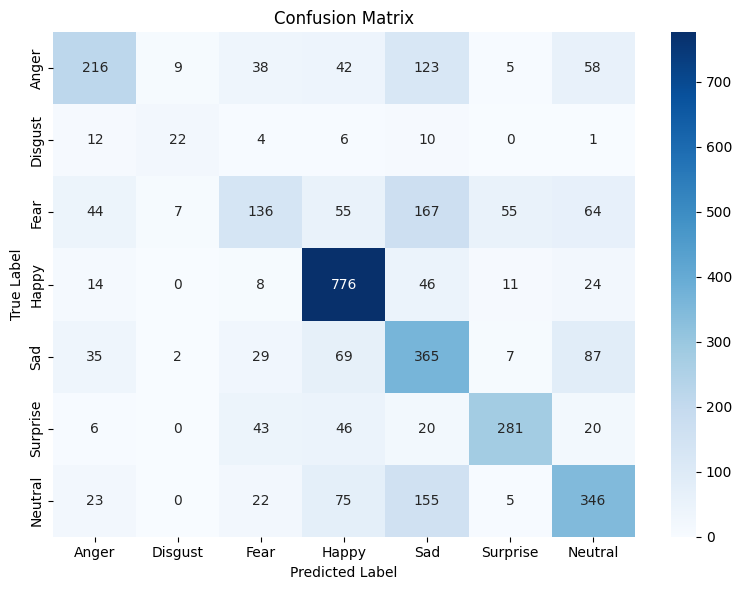

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_map, yticklabels=label_map)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


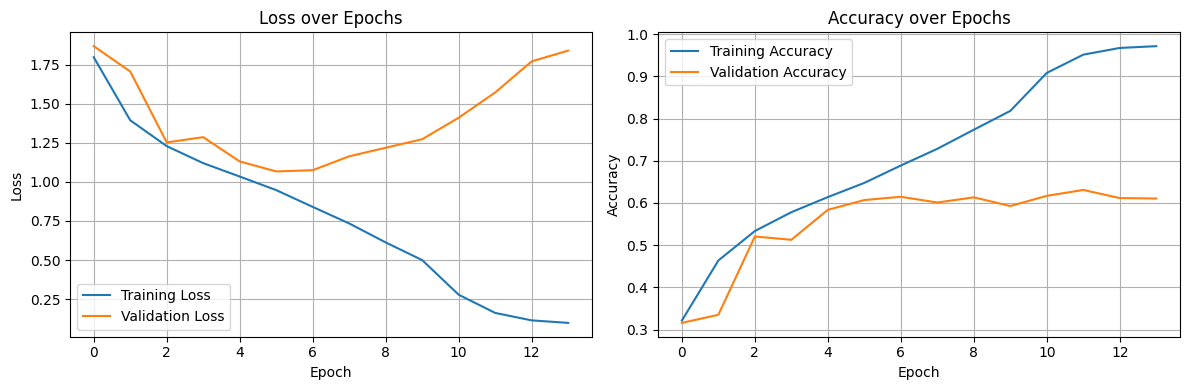

In [ ]:
# === 展示 Loss 與 Accuracy 隨 Epoch 變化 ===

# 繪製 Loss 曲線圖
plt.figure(figsize=(12, 4))

# Loss 圖
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy 圖
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
